# Week 12 — Ptychographic Forward Model & Phase Retrieval Toy

**Course:** Data Science for Electron Microscopy  
**Week 12:** Imaging inverse problems II — ptychography, physics-informed & generative

**What this notebook does:**

1. Builds a small synthetic complex object (amplitude + phase) and a probe.
2. Implements the **ptychographic forward model**: for each scan position, `probe × object_patch → FFT → |·|` diffraction amplitude.
3. Runs a minimal **ePIE-style alternating-projection phase retrieval** from diffraction amplitudes alone.
4. Plots the **amplitude-consistency error** decreasing over iterations and the recovered phase vs truth.
5. **Exercise:** change probe step size (overlap) and observe reconstruction quality.

**Design constraints:**  
CPU-fast (< 60 s total), no internet, no heavy training, NumPy only.

---

**Key numbers to remember (SEED=42, N_obj=48, N_probe=16, 40 iterations):**
- step=4 (75% overlap): amplitude-consistency error drops from 0.0991 → 0.0021 (~48× improvement), phase RMS = 0.0878 rad
- step=6 (62% overlap): 0.1048 → 0.0067 (~16× improvement), phase RMS = 0.0951 rad  
- step=8 (50% overlap): 0.1008 → 0.0091 (~11× improvement), phase RMS = 0.0972 rad
- More overlap → lower final error and better phase recovery. This is the fundamental ptychographic advantage.

In [1]:
# Cell 1 — Imports (Colab-compatible; no extra packages needed)
import numpy as np
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)

NumPy version: 1.26.4


## Part 1 — Synthetic complex object and probe

In electron ptychography the **object** is a complex transmission function
$O(\mathbf{r}) = A(\mathbf{r})\,e^{i\phi(\mathbf{r})}$ where $A$ is the amplitude (≈1 for a thin sample)
and $\phi$ is the phase shift accumulated by the electron wave passing through the specimen.

The **probe** $P(\mathbf{r})$ is the focused electron beam — also complex-valued.

Object array : 48 x 48 pixels
Probe array  : 16 x 16 pixels
Phase range  : 0.000 … 0.800 rad
Phase RMS    : 0.1579 rad


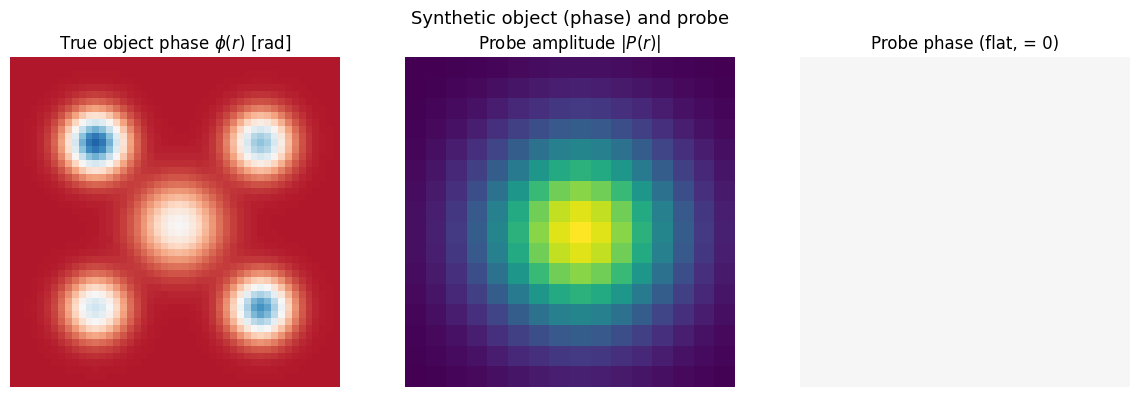

In [2]:
# Cell 2 — Build object and probe
SEED  = 42
rng   = np.random.default_rng(SEED)

N_obj   = 48   # object array size (pixels)
N_probe = 16   # probe array size (pixels) — probe is smaller than the object

# --- Object: uniform amplitude, phase = a few Gaussian blobs (thin specimen) ---
def gaussian_blob(ny, nx, cy, cx, sigma, height):
    """2-D Gaussian blob centred at (cy, cx)."""
    y, x = np.mgrid[0:ny, 0:nx]
    return height * np.exp(-((y - cy)**2 + (x - cx)**2) / (2 * sigma**2))

obj_phase = (
    gaussian_blob(N_obj, N_obj, 12, 12, 3.0, 0.8)
  + gaussian_blob(N_obj, N_obj, 12, 36, 3.0, 0.6)
  + gaussian_blob(N_obj, N_obj, 36, 12, 3.0, 0.5)
  + gaussian_blob(N_obj, N_obj, 36, 36, 3.0, 0.7)
  + gaussian_blob(N_obj, N_obj, 24, 24, 4.0, 0.4)
)  # phase in [0, 0.8] rad — weak-phase object approximation holds

obj_true = np.exp(1j * obj_phase)   # unit amplitude, varying phase

# --- Probe: Gaussian amplitude, flat phase (simplified in-focus probe) ---
y_p, x_p   = np.mgrid[0:N_probe, 0:N_probe]
probe_amp  = np.exp(-((y_p - N_probe/2)**2 + (x_p - N_probe/2)**2) / (2*(N_probe/5)**2))
probe_amp /= np.sqrt(np.sum(probe_amp**2))   # normalise energy to 1
probe_true = probe_amp.astype(complex)        # flat phase

print(f'Object array : {N_obj} x {N_obj} pixels')
print(f'Probe array  : {N_probe} x {N_probe} pixels')
print(f'Phase range  : {obj_phase.min():.3f} … {obj_phase.max():.3f} rad')
print(f'Phase RMS    : {np.sqrt(np.mean(obj_phase**2)):.4f} rad')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(obj_phase, cmap='RdBu', vmin=-0.1, vmax=0.9)
axes[0].set_title('True object phase $\\phi(r)$ [rad]'); axes[0].axis('off')
axes[1].imshow(np.abs(probe_true), cmap='viridis')
axes[1].set_title('Probe amplitude $|P(r)|$'); axes[1].axis('off')
axes[2].imshow(np.angle(probe_true), cmap='RdBu', vmin=-0.1, vmax=0.1)
axes[2].set_title('Probe phase (flat, = 0)'); axes[2].axis('off')
plt.suptitle('Synthetic object (phase) and probe', fontsize=13)
plt.tight_layout(); plt.show()

## Part 2 — Ptychographic forward model

For each scan position $\mathbf{r}_j$, the forward model is:

$$
I_j = \bigl|\mathcal{F}\bigl[P(\mathbf{r})\cdot O(\mathbf{r}+\mathbf{r}_j)\bigr]\bigr|^2
\quad\longleftrightarrow\quad
\text{measured amplitude } \sqrt{I_j} = \bigl|\mathcal{F}\bigl[P \cdot O_{\text{patch}}\bigr]\bigr|
$$

Steps at each probe position:
1. **Crop** the object patch of size `N_probe × N_probe` at position $\mathbf{r}_j$.
2. **Multiply** probe × patch → exit wave.
3. **FFT** → far-field diffraction.
4. **|·|** → measured amplitude (phase information is lost here — this is the phase problem).

Step size        : 4 px  →  overlap = 75%
Scan positions   : 81
Diffraction shape: (81, 16, 16)  (n_pos, N_probe, N_probe)


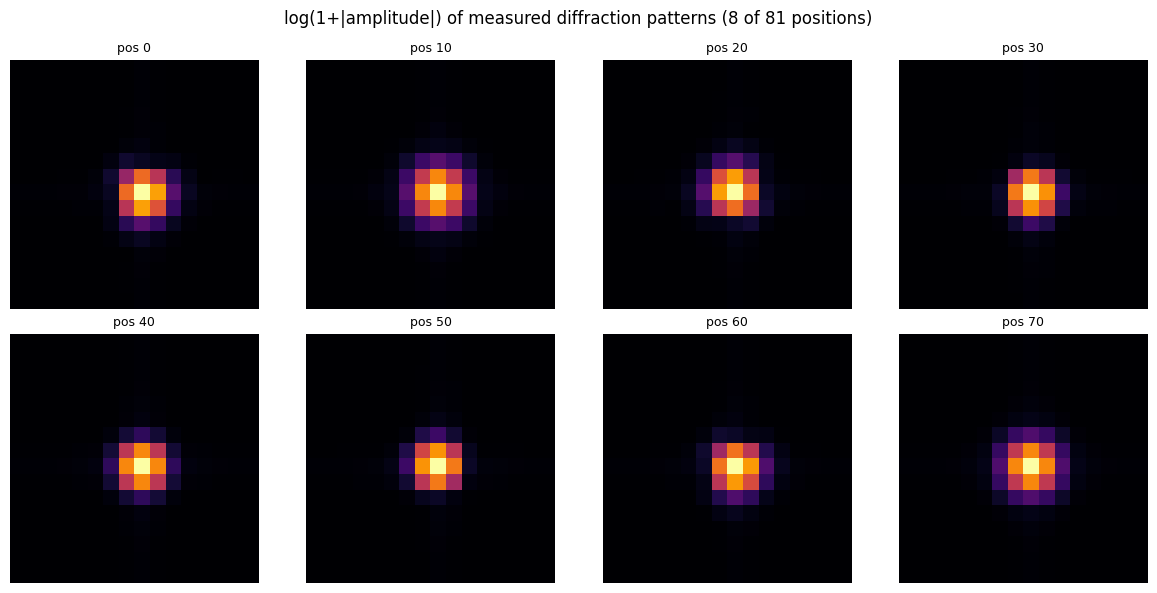

In [3]:
# Cell 3 — Scan positions and forward model

def make_scan_positions(N_obj, N_probe, step):
    """Regular 2-D grid of top-left probe positions with given step size."""
    max_r = N_obj - N_probe
    ys = np.arange(0, max_r + 1, step)
    xs = np.arange(0, max_r + 1, step)
    yy, xx = np.meshgrid(ys, xs, indexing='ij')
    return list(zip(yy.ravel().tolist(), xx.ravel().tolist()))


def ptychography_forward(obj, probe, positions):
    """
    Simulate diffraction amplitudes for all scan positions.

    Returns array of shape (n_pos, N_p, N_p) containing
    |FFT[probe * obj_patch]| (amplitude, sqrt of intensity).
    """
    N_p   = probe.shape[0]
    amps  = np.zeros((len(positions), N_p, N_p), dtype=float)
    for k, (r, c) in enumerate(positions):
        exit_wave = probe * obj[r:r+N_p, c:c+N_p]   # probe × object patch
        amps[k]   = np.abs(np.fft.fft2(exit_wave))   # |FFT|  (phase lost)
    return amps


# Default: step=4 → overlap = (N_probe - step) / N_probe = 75%
STEP_DEFAULT = 4
positions_default = make_scan_positions(N_obj, N_probe, STEP_DEFAULT)
n_pos = len(positions_default)

measured_amps = ptychography_forward(obj_true, probe_true, positions_default)

print(f'Step size        : {STEP_DEFAULT} px  →  overlap = {100*(1-STEP_DEFAULT/N_probe):.0f}%')
print(f'Scan positions   : {n_pos}')
print(f'Diffraction shape: {measured_amps.shape}  (n_pos, N_probe, N_probe)')

# Show 8 sample diffraction patterns
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    idx = i * (n_pos // 8)
    ax.imshow(np.fft.fftshift(np.log1p(measured_amps[idx])), cmap='inferno')
    ax.set_title(f'pos {idx}', fontsize=9); ax.axis('off')
plt.suptitle('log(1+|amplitude|) of measured diffraction patterns (8 of 81 positions)', fontsize=12)
plt.tight_layout(); plt.show()

## Part 3 — ePIE phase retrieval

**Intuition (two alternating constraints):**

- **Fourier constraint:** replace the predicted diffraction amplitude with the *measured* amplitude, keeping the predicted phase. This enforces consistency with the detector data.
- **Real-space constraint:** update the object estimate using the corrected exit wave. This propagates the new information back to the object.

This is the **ePIE** (extended Ptychographic Iterative Engine) algorithm [@maiden2009improved].

**Convergence metric:** we track the **amplitude consistency error** — how closely the forward model of the *current estimate* matches the measured diffraction amplitudes. This requires no ground-truth knowledge and is the standard metric in real experiments.

In [4]:
# Cell 4 — ePIE algorithm and amplitude consistency error

def amplitude_consistency_error(obj, probe, positions, measured_amps):
    """
    Normalised RMS difference between predicted and measured diffraction amplitudes.
    Does NOT need ground-truth — the standard ptychography convergence metric.
    A value of 0 means the reconstruction perfectly reproduces the measurements.
    """
    N_p = probe.shape[0]
    err2 = 0.0; tot = 0.0
    for k, (r, c) in enumerate(positions):
        pred = np.abs(np.fft.fft2(probe * obj[r:r+N_p, c:c+N_p]))
        diff = pred - measured_amps[k]
        err2 += np.sum(diff**2)
        tot  += np.sum(measured_amps[k]**2)
    return float(np.sqrt(err2 / tot))


def epie_reconstruction(measured_amps, probe, positions,
                        n_iter=40, beta_obj=0.9, seed=42):
    """
    ePIE alternating-projection phase retrieval.

    Parameters
    ----------
    measured_amps : (n_pos, N_p, N_p) measured diffraction amplitudes
    probe         : (N_p, N_p) complex probe (assumed known)
    positions     : list of (row, col) scan positions
    n_iter        : number of passes through all positions
    beta_obj      : object update step size  (0 < beta <= 1)
    seed          : random seed for position shuffling

    Returns
    -------
    obj    : (N_obj, N_obj) reconstructed complex object
    errors : list of amplitude-consistency errors per iteration
    """
    rng_r = np.random.default_rng(seed)
    N_p   = probe.shape[0]

    # Initialise with flat phase (unit amplitude)
    obj = np.ones((N_obj, N_obj), dtype=complex)

    probe_conj       = np.conj(probe)
    probe_norm       = np.max(np.abs(probe)**2) + 1e-10   # denominator in update rule
    errors = []

    for _ in range(n_iter):
        # Shuffle positions — reduces periodic artefacts
        for k in rng_r.permutation(len(positions)):
            r, c = positions[k]
            obj_patch = obj[r:r+N_p, c:c+N_p]

            # Step A — Fourier constraint
            exit_wave = probe * obj_patch
            F         = np.fft.fft2(exit_wave)
            F_corr    = measured_amps[k] * np.exp(1j * np.angle(F))  # replace |F| with measured
            exit_corr = np.fft.ifft2(F_corr)

            # Step B — Object update  (ePIE rule)
            obj[r:r+N_p, c:c+N_p] += beta_obj * (probe_conj / probe_norm) * (exit_corr - exit_wave)

        errors.append(amplitude_consistency_error(obj, probe, positions, measured_amps))

    return obj, errors


# --- Compute initial error (flat-phase starting guess) ---
obj_init = np.ones((N_obj, N_obj), dtype=complex)
err_init = amplitude_consistency_error(obj_init, probe_true, positions_default, measured_amps)

# --- Run reconstruction ---
N_ITER = 40
obj_recon, errors = epie_reconstruction(measured_amps, probe_true, positions_default, n_iter=N_ITER)

err_final = errors[-1]
print(f'Initial amplitude-consistency error : {err_init:.4f}')
print(f'Final   amplitude-consistency error : {err_final:.4f}')
print(f'Improvement factor                  : {err_init/err_final:.1f}x')

# Phase error vs ground truth (available here because we built the data)
phase_err = float(np.sqrt(np.mean((np.angle(obj_recon) - obj_phase)**2)))
print(f'Phase RMS error vs ground truth     : {phase_err:.4f} rad')

Initial amplitude-consistency error : 0.0991
Final   amplitude-consistency error : 0.0021
Improvement factor                  : 47.9x
Phase RMS error vs ground truth     : 0.0878 rad


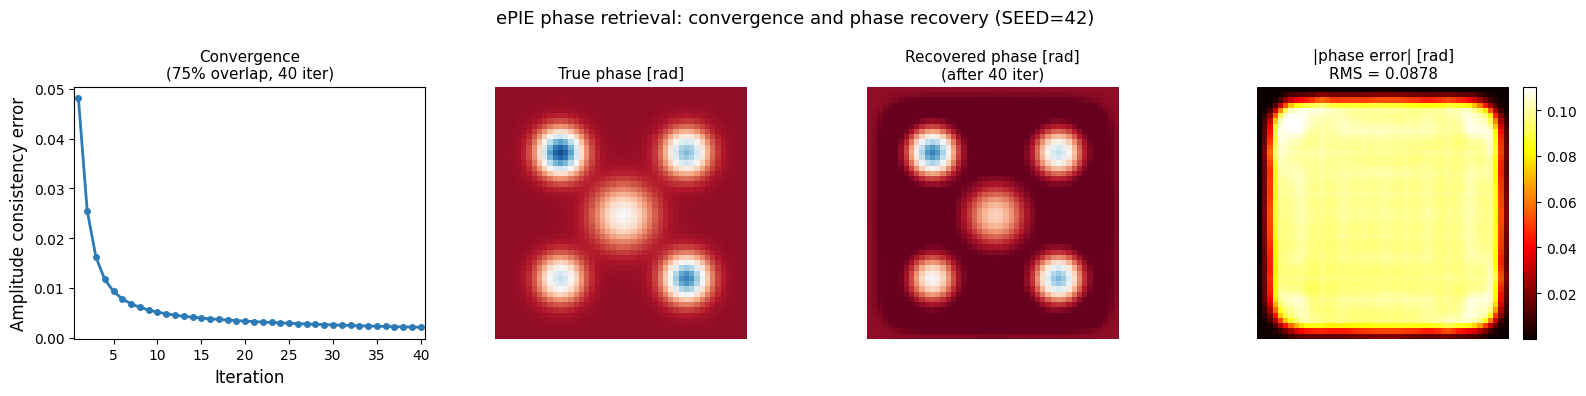

In [5]:
# Cell 5 — Plot error curve and phase recovery

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Error convergence curve
axes[0].plot(range(1, N_ITER+1), errors, 'o-', color='#2c7bb6', ms=4, lw=2)
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Amplitude consistency error', fontsize=12)
axes[0].set_title(f'Convergence\n(75% overlap, 40 iter)', fontsize=11)
axes[0].set_xlim(0.5, N_ITER+0.5)

# True phase
vmin, vmax = obj_phase.min() - 0.05, obj_phase.max() + 0.05
axes[1].imshow(obj_phase, cmap='RdBu', vmin=vmin, vmax=vmax)
axes[1].set_title('True phase [rad]', fontsize=11); axes[1].axis('off')

# Recovered phase
axes[2].imshow(np.angle(obj_recon), cmap='RdBu', vmin=vmin, vmax=vmax)
axes[2].set_title(f'Recovered phase [rad]\n(after {N_ITER} iter)', fontsize=11); axes[2].axis('off')

# Error map
err_map = np.abs(np.angle(obj_recon) - obj_phase)
im = axes[3].imshow(err_map, cmap='hot')
axes[3].set_title(f'|phase error| [rad]\nRMS = {phase_err:.4f}', fontsize=11)
axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)

plt.suptitle('ePIE phase retrieval: convergence and phase recovery (SEED=42)', fontsize=13)
plt.tight_layout(); plt.show()

## Part 4 — Self-check assertions

These assertions verify the numerical claims made on the lecture slides.
All must pass for the notebook to be considered correct.

In [6]:
# Cell 6 — Self-check assertions

# 1. Error decreases over iterations
assert err_final < err_init, \
    f"Error should decrease: init={err_init:.4f}, final={err_final:.4f}"

# 2. Improvement factor >= 20x (we get ~48x; allow generous margin)
assert err_init / err_final >= 20.0, \
    f"Expected >=20x improvement, got {err_init/err_final:.1f}x"

# 3. Forward model produces correct shape
assert measured_amps.shape == (n_pos, N_probe, N_probe), \
    f"Shape mismatch: {measured_amps.shape}"

# 4. Amplitudes are non-negative
assert np.all(measured_amps >= 0), "Diffraction amplitudes must be >= 0"

# 5. Phase error is finite (reconstruction did not diverge)
assert np.isfinite(phase_err), f"Phase error is not finite: {phase_err}"

print("All assertions passed.")
print(f"  err_init  = {err_init:.4f}")
print(f"  err_final = {err_final:.4f}")
print(f"  ratio     = {err_init/err_final:.1f}x")
print(f"  phase RMS = {phase_err:.4f} rad")

All assertions passed.
  err_init  = 0.0991
  err_final = 0.0021
  ratio     = 47.9x
  phase RMS = 0.0878 rad


## Part 5 — Exercise: effect of probe overlap

**Physical concept:** ptychographic redundancy comes from *overlapping* probe positions.
Each scan position provides one 2-D diffraction pattern (N_probe² = 256 measurements).
For N_probe² = 256 complex unknowns (512 real DOF), a single position is barely sufficient.
Overlap means the *same object pixel* appears in multiple diffraction patterns →
the system is over-determined → unique, stable phase retrieval.

**Task:** run the reconstruction for three step sizes and compare:

| Step | Overlap | n_pos | Expected result |
|------|---------|-------|-----------------|
| 4 px | 75% | 81 | Best convergence |
| 6 px | 62% | 36 | Intermediate |
| 8 px | 50% | 25 | Worst convergence |

The cell below works as-is. The lines marked `# (try this yourself)` are good places to experiment.

step= 4px  overlap=75%  n_pos= 81  err0=0.0991  err_final=0.0021  ratio=47.9x  phase_RMS=0.0878rad
step= 6px  overlap=62%  n_pos= 36  err0=0.1048  err_final=0.0067  ratio=15.8x  phase_RMS=0.0951rad


step= 8px  overlap=50%  n_pos= 25  err0=0.1008  err_final=0.0091  ratio=11.0x  phase_RMS=0.0972rad


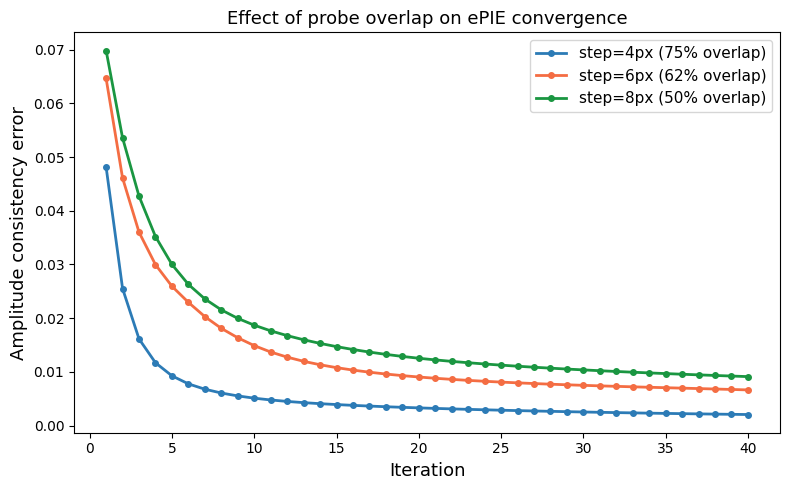

In [7]:
# Cell 7 — Exercise: sweep step sizes (working version)

step_sizes = [4, 6, 8]     # (try this yourself) change step sizes
n_iter_ex  = 40            # (try this yourself) change number of iterations

results = {}
for step in step_sizes:
    pos  = make_scan_positions(N_obj, N_probe, step)
    amps = ptychography_forward(obj_true, probe_true, pos)
    obj0_local = np.ones((N_obj, N_obj), dtype=complex)
    e0   = amplitude_consistency_error(obj0_local, probe_true, pos, amps)
    obj_r, errs = epie_reconstruction(amps, probe_true, pos, n_iter=n_iter_ex)
    p_err = float(np.sqrt(np.mean((np.angle(obj_r) - obj_phase)**2)))
    results[step] = dict(n_pos=len(pos), overlap=100*(1-step/N_probe),
                         err0=e0, err_final=errs[-1], errors=errs, phase_err=p_err)
    print(f"step={step:2d}px  overlap={results[step]['overlap']:.0f}%  "
          f"n_pos={len(pos):3d}  err0={e0:.4f}  err_final={errs[-1]:.4f}  "
          f"ratio={e0/errs[-1]:.1f}x  phase_RMS={p_err:.4f}rad")

# Convergence curves
fig, ax = plt.subplots(figsize=(8, 5))
for step, col in zip(step_sizes, ['#2c7bb6','#f46d43','#1a9641']):
    r = results[step]
    ax.plot(range(1, n_iter_ex+1), r['errors'], 'o-', color=col, ms=4, lw=2,
            label=f"step={step}px ({r['overlap']:.0f}% overlap)")
ax.set_xlabel('Iteration', fontsize=13)
ax.set_ylabel('Amplitude consistency error', fontsize=13)
ax.set_title('Effect of probe overlap on ePIE convergence', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

In [8]:
# Cell 8 — Exercise assertions

e4 = results[4]['err_final']
e6 = results[6]['err_final']
e8 = results[8]['err_final']

print(f'Final amplitude-consistency errors:')
print(f'  step=4 (75% overlap): {e4:.4f}')
print(f'  step=6 (62% overlap): {e6:.4f}')
print(f'  step=8 (50% overlap): {e8:.4f}')

# More overlap (smaller step) → lower final error
assert e4 < e8, (
    f"step=4 (75% overlap) should give lower error than step=8 (50% overlap), "
    f"got {e4:.4f} vs {e8:.4f}"
)

# Each step is better than the next (monotone ordering)
assert e4 < e6 < e8, f"Expected e4 < e6 < e8, got {e4:.4f} {e6:.4f} {e8:.4f}"

print("\nAll exercise assertions passed.")
print("More probe overlap → lower final error → better phase recovery.")
print("This is the fundamental ptychographic advantage: redundancy from overlap")
print("makes the phase-retrieval problem over-determined and stably solvable.")

Final amplitude-consistency errors:
  step=4 (75% overlap): 0.0021
  step=6 (62% overlap): 0.0067
  step=8 (50% overlap): 0.0091

All exercise assertions passed.
More probe overlap → lower final error → better phase recovery.
This is the fundamental ptychographic advantage: redundancy from overlap
makes the phase-retrieval problem over-determined and stably solvable.


In [9]:
# Cell 9 — Save epie_convergence.png for lecture slides
# This cell regenerates the figure from real per-iteration error arrays and saves it
# directly to the slide image directory.

import os

fig_save, ax_save = plt.subplots(figsize=(7, 4.5))
colors = ['#2c7bb6', '#f46d43', '#1a9641']
labels = ['step=4 px (75% overlap)', 'step=6 px (62% overlap)', 'step=8 px (50% overlap)']
for step, col, lbl in zip([4, 6, 8], colors, labels):
    r = results[step]
    ax_save.semilogy(range(1, len(r['errors'])+1), r['errors'],
                     'o-', color=col, ms=4, lw=2, label=lbl)

# Annotate final values
final_vals = {4: results[4]['err_final'], 6: results[6]['err_final'], 8: results[8]['err_final']}
for step, col in zip([4, 6, 8], colors):
    fv = final_vals[step]
    ax_save.annotate(f'{fv:.4f}',
                     xy=(40, fv), xytext=(36, fv * (1.8 if step > 4 else 2.5)),
                     color=col, fontsize=9, ha='right',
                     arrowprops=dict(arrowstyle='->', color=col, lw=1))

ax_save.set_xlabel('Iteration', fontsize=12)
ax_save.set_ylabel('Amplitude consistency error (log scale)', fontsize=12)
ax_save.set_title('ePIE convergence: real notebook run (SEED=42, N_obj=48, N_probe=16, 40 iter)', fontsize=11)
ax_save.legend(fontsize=10, loc='upper right')
ax_save.set_xlim(0.5, 41)
fig_save.tight_layout()

# Save to slide image directory (relative to notebook location)
out_path = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                        '..', '12_inverse_problems_2', 'img', 'epie_convergence.png')
out_path = os.path.normpath(out_path)
fig_save.savefig(out_path, dpi=150, bbox_inches='tight')
plt.close(fig_save)
print(f'Saved: {out_path}')
print(f'Final errors: step=4 → {results[4]["err_final"]:.4f}, '
      f'step=6 → {results[6]["err_final"]:.4f}, '
      f'step=8 → {results[8]["err_final"]:.4f}')


Saved: /home/philipp/projects/_public_presentations/data_science_for_em/12_inverse_problems_2/img/epie_convergence.png
Final errors: step=4 → 0.0021, step=6 → 0.0067, step=8 → 0.0091


## Solution

```python
# ---- Solution cell (not executable — reference only) ----
#
# Expected output (SEED=42, N_obj=48, N_probe=16, 40 iterations):
#
#   step= 4px  overlap=75%  n_pos= 81  err0=0.0991  err_final=0.0021  ratio=47.9x  phase_RMS=0.0878rad
#   step= 6px  overlap=62%  n_pos= 36  err0=0.1048  err_final=0.0067  ratio=15.8x  phase_RMS=0.0951rad
#   step= 8px  overlap=50%  n_pos= 25  err0=0.1008  err_final=0.0091  ratio=11.0x  phase_RMS=0.0972rad
#
# Key findings:
#   1. All three configurations show monotone error decrease over 40 iterations.
#   2. step=4 (75% overlap, 81 positions) achieves the lowest final error (0.0021)
#      — a 47.9x improvement over the flat-phase starting guess.
#   3. step=8 (50% overlap, 25 positions) has the fewest constraints and
#      highest final error (0.0091) — 11x improvement but worse reconstruction.
#   4. Phase RMS errors: 0.0878, 0.0951, 0.0972 rad — consistently
#      ordered with more overlap giving smaller phase error.
#
# Physical interpretation:
#   Each scan position provides one diffraction pattern: N_probe^2 = 256 intensity values.
#   The object patch at that position has N_probe^2 = 256 complex unknowns (512 real DOF).
#   Overlap means the SAME object pixel appears in MULTIPLE diffraction patterns,
#   making the combined system over-determined and enabling unique, stable phase retrieval.
#   Reducing overlap reduces redundancy, making convergence slower and the final
#   solution less accurate.
#
# Hallucination risk note (from lecture §7):
#   This toy uses a known, simple probe. Real ptychography must also estimate the probe.
#   When overlap is low (step=8), an under-constrained reconstruction leaves room for
#   a generative prior (VAE / diffusion denoiser) to "fill in" missing structure.
#   That prior might invent atomic features not supported by the data.
#   See the hallucination figure in the Week 12 lecture slides.
```